In [ ]:
import os, torch, cv2, tqdm
import numpy as np
import tensorly as tl
import matplotlib.pyplot as plt
from readlif.reader import LifFile, LifImage
import xml.etree.ElementTree as ET
from sklearn.cluster import KMeans

import preprocessing.microscopy_image as mi
import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import constants

## Constants Definition

In [3]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Nina"
SAMPLE_ID = "00103993-1"
MODALITY_NAME = "raman"

INPUT_PATH = os.path.join(PATH, SAMPLE_ID, MODALITY_NAME)
OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)
FILENAME = f"{SAMPLE_ID}.lif"

## Leica LIF File loader

In [4]:
def compute_wavenumbers(lambda_begin: float, lambda_end: float, lambda_steps: float, lamnda_stokes: float) -> np.ndarray[np.float32]:
    '''
    Compute the wavenumbers array based on the LIF File metadata
    
    Parameters
    ----------
    lambda_begin : float
        The starting wavelength in nm.
    lambda_end : float
        The ending wavelength in nm.
    lambda_steps : float
        The number of steps in the wavelength range.
    lambda_stokes : float
        The Stokes wavelength in nm.
    '''

    # Compute the laser pump wavelength
    pump_wavelength = np.linspace(lambda_begin, lambda_end, lambda_steps)

    # Compute the Raman wavenumbers
    raman_wavenumbers = ((1 / pump_wavelength) - (1 / lamnda_stokes)) * 1e7

    return raman_wavenumbers

def parse_lif_metadata(lif: LifFile) -> list[dict]:
    
    # Obtain the XML root element from the LifFile object
    root = lif.xml_root

    # Obtain a list of Raman Scans
    top_level_elements = root.findall('./Element')
    if not top_level_elements:
        top_level_elements = root.findall('.')
        if root.tag != 'Element':
                top_level_elements = root.findall('.//Element')

    # Filter out the elements that do not represent scans
    elements_to_process = []
    for top_element in top_level_elements:
        children_tag = top_element.find('Children')
        if children_tag is not None:
            for image_element in children_tag.findall('Element'):
                elements_to_process.append(image_element)
        else:
                if top_element.find('./Data/Image') is not None:
                    elements_to_process.append(top_element)

    # Fallback in case the XML structure is collapsed to a single level
    if not elements_to_process and root.tag == 'LMSDataContainerHeader':
        root_children_tag = root.find('Children')
        if root_children_tag is not None:
            for image_element in root_children_tag.findall('Element'):
                elements_to_process.append(image_element)
        elif root.find('./Element/Data/Image') is not None :
                for image_element in root.findall('Element'):
                    if image_element.find('./Data/Image') is not None:
                        elements_to_process.append(image_element)

    # No elements to process or unexpected structure
    if not elements_to_process:
        raise ValueError("No elements found in the LIF file or unexpected XML structure.")

    result = []

    # Iterate over each element to extract metadata
    for i, element in enumerate(elements_to_process):
        element_name = element.get('Name', f"Unnamed Element {i+1}")
        data_image_tag = element.find('./Data/Image')
        
        metadata = {
            "scan_name": element_name,
            "lambda_steps": None,
            "lambda_begin": None,
            "lambda_end": None,
            "scan_height": None,
            "scan_width": None,
            "laser_type": None,
            "lambda_stokes": None,
            "tile_number": None,
            "tiles_location": None,
        }

        # Get the dimensions
        if data_image_tag is not None:
            image_description = data_image_tag.find('ImageDescription')
            if image_description is not None:                
                dimensions = image_description.find('Dimensions')
                if dimensions is not None and len(list(dimensions)) > 0:
                    for dim_desc in dimensions.findall('DimensionDescription'):
                        id = int(dim_desc.get('DimID', None))
                        size = int(dim_desc.get('NumberOfElements', None))

                        # Interpret the dimension ID for standard Leica LIF files
                        if id == 1:
                            metadata["scan_height"] = size
                        elif id == 2:
                            metadata["scan_width"] = size
                        elif id == 9:
                            metadata["lambda_steps"] = size
                        elif id == 10:
                            metadata["tile_number"] = size

        # Define potential paths for ATLConfocalSettingDefinition
        atl_confocal_paths = [
            './Data/Image/Attachment[@Name="HardwareSetting"]/ATLConfocalSettingDefinition',
            './Data/Image/Attachment[@Name="HardwareSetting"]/LDM_Block_Sequential/LDM_Block_Sequential_Master/ATLConfocalSettingDefinition'
        ]

        found_lambda, found_stokes = False, False

        # Extract Begin and End for Lambda Steps + Lambda Stokes (constant)
        for _, atl_path in enumerate(atl_confocal_paths):
            atl_confocal_setting_def = element.find(atl_path)
            if atl_confocal_setting_def is not None:
                if not found_lambda: 
                    lambda_definition = atl_confocal_setting_def.find('LambdaDefinition')
                    if lambda_definition is not None and len(list(lambda_definition)) > 0:
                        lambda_excitation = lambda_definition.find('LambdaExcitation')
                        
                        if lambda_excitation is not None:
                            metadata["lambda_begin"] = float(lambda_excitation.get('LambdaExcitationBeginDouble', None))
                            metadata["lambda_end"] = float(lambda_excitation.get('LambdaExcitationEndDouble', None))
                            found_lambda = True

                # Extract Lambda Stokes (Pump Wavelength)
                if not found_stokes:
                    laser_array = atl_confocal_setting_def.find('LaserArray')
                    if laser_array is not None:
                        lasers_with_pumpwavelength = []
                        for laser_tag in laser_array.findall('Laser'):
                            pump_wavelength = laser_tag.get('PumpWavelength')
                            if pump_wavelength is not None:
                                laser_name = laser_tag.get('LaserName', 'Unknown Laser')
                                lasers_with_pumpwavelength.append(
                                    f"<Laser Name='{laser_name}' PumpWavelength='{pump_wavelength}' />"
                                )
                        
                        if lasers_with_pumpwavelength:
                            for entry in lasers_with_pumpwavelength:
                                # Parse the entry string into an XML element
                                entry_element = ET.fromstring(entry)
                                metadata["laser_type"] = entry_element.get('Name', None)
                                metadata["lambda_stokes"] = float(entry_element.get('PumpWavelength', None))
                                found_stokes = True
            if found_lambda and found_stokes:
                break
        
        # If the image represents a tile scan, extract info about the tiles
        if metadata["tile_number"] is not None and metadata["tile_number"] > 1:
            tiles = element.findall('./Data/Image/Attachment[@Name="TileScanInfo"]/Tile')
            tiles_metadata = []

            for tile in tiles:
                tiles_metadata.append({
                    "x": float(tile.get('PosX')),
                    "y": float(tile.get('PosY')),
                })
            
            metadata["tiles_location"] = tiles_metadata

        # Append the metadata to the list
        result.append(metadata)

    return result

def load_raman_lif(file: str) -> list[dict]:
    '''
    Load Raman Spectroscopy Imageing data from a Leica LIF file.

    Parameters
    ----------
    file : str
        Path to the LIF file.

    Returns
    ----------
    lif_data : list[dict]
        List of dictionaries containing the image data and metadata.
        Each dictionary contains:
            - "data": List of tiles, each tile is a 3D numpy array (height, width, lambda_steps).
            - "metadata": Dictionary with metadata for the corresponding image.
    '''
    
    lif_file = LifFile(file)
    metadata_array = parse_lif_metadata(lif_file)

    lif_data: list[dict] = []

    # Iterate over the images following the order written in metadata
    for index, metadata in enumerate(metadata_array):

        # Extract only tiled images, ignore automatic stitching
        if metadata["tile_number"] is None or metadata["tile_number"] < 2:
            continue

        # Read the image
        image: LifImage = lif_file.get_image(index)
        tiles: list[np.ndarray[np.float32]] = []

        # Read the tiles
        for tile_idx in range(metadata["tile_number"]):
            tile = np.zeros((metadata["scan_width"], metadata["scan_height"], metadata["lambda_steps"]), dtype=np.float32)

            # For each tile, iterate over the spectral dimensions
            for spectral_idx in range(metadata["lambda_steps"]):
                # Read the image data for each lambda step
                plane = image.get_plane(display_dims=(1, 2), c = 0, requested_dims = {9: spectral_idx, 10: tile_idx})

                # Convert the plane to a numpy array and normalize it between 0 and 1
                plane = np.array(plane, dtype=np.float32)
                plane = cv2.normalize(plane, None, 0, 1, cv2.NORM_MINMAX)
                tile[:, :, spectral_idx] = plane

            # Save the tile
            tiles.append(tile)

        # Save the tile
        lif_data.append({"data": tiles, "metadata": metadata, "wavenumbers": compute_wavenumbers(metadata["lambda_begin"], metadata["lambda_end"], metadata["lambda_steps"], metadata["lambda_stokes"])})

    return lif_data
            

## Tile processing

In [5]:
def compute_variance_over_spectral_dimensions(
    tile: np.ndarray[np.float32], 
    gamma_correction_factor: float | None = None,
    contrast_enhancement_factor: float | None = None,
    low_variance_threshold: float | None = None,
    high_variance_threshold: float | None = None) -> np.ndarray[np.float32]:
    
    '''
    Compute the variance over the spectral dimensions of a Raman Specroscopy Image tile.

    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The tile to compute the variance over. Expected normalized values with spectral dimension in the last axis.
    gamma_correction_factor : float | None
        The gamma correction factor to apply. Default is None. If None, no correction is applied.
    contrast_enhancement_factor : float | None
        Percentage of pixels to saturate to perform contrast enhancement. Default is None. If None, no enhancement is applied.
    low_variance_threshold : float | None
        Bottom percentile to force to zero variance. Default is None. If None, no threshold is applied.
    high_variance_threshold : float | None
        Top percentile to force to zero variance. Default is None. If None, no threshold is applied.
    
    Returns
    ----------
    np.ndarray[np.float32]
        The variance over the spectral dimensions.
    '''

    # Check the input
    if type(tile) != np.ndarray or len(tile.shape) != 3 or tile.dtype != np.float32:
        raise ValueError("Input tile must be a 3D float32 numpy array with shape (height, width, lambda_steps).")
    
    if low_variance_threshold is not None and (low_variance_threshold < 0 or low_variance_threshold > 1):
        raise ValueError("low_variance_threshold must be between 0 and 1.")
    if high_variance_threshold is not None and (high_variance_threshold < 0 or high_variance_threshold > 1):
        raise ValueError("high_variance_threshold must be between 0 and 1.")
    if contrast_enhancement_factor is not None and (contrast_enhancement_factor < 0 or contrast_enhancement_factor > 1):
        raise ValueError("contrast_enhancement_factor must be between 0 and 1.")
    if gamma_correction_factor is not None and (gamma_correction_factor < 0 or gamma_correction_factor > 1):
        raise ValueError("gamma_correction_factor must be between 0 and 1.")

    # Normalize if necessary
    if (np.min(tile) < 0) or (np.max(tile) > 1):
        tile = cv2.normalize(tile, None, 0, 1, cv2.NORM_MINMAX)

    # Compute the variance over the spectral dimensions
    variance = np.var(tile, axis=-1)

    # Normalize the variance
    variance = cv2.normalize(variance, None, 0, 1, cv2.NORM_MINMAX)

    # Apply gamma correction if requested
    if gamma_correction_factor is not None:
        variance = mi.gamma_correction(variance, gamma = gamma_correction_factor)

    # Apply contrast enhancement if requested
    if contrast_enhancement_factor is not None:
        variance = mi.enhance_contrast(variance, saturated_pixels = contrast_enhancement_factor)

    # Apply low variance threshold if requested
    if low_variance_threshold is not None:
        low_threshold = np.percentile(variance, low_variance_threshold * 100)
        variance[variance < low_threshold] = 0

    # Apply high variance threshold if requested
    if high_variance_threshold is not None:
        high_threshold = np.percentile(variance, high_variance_threshold * 100)
        variance[variance > high_threshold] = 0

    # Apply final normalization
    variance = cv2.normalize(variance, None, 0, 1, cv2.NORM_MINMAX)

    return variance

In [26]:
def compute_variance_over_region(tile: np.ndarray[np.float32], kernel_size: int = 3):
    '''
    Compute the variance over a region of the tile using a local mean and local squared mean.
    
    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The tile to compute the variance over. Expected normalized 2D/3D matrix. For 3D, the last axis is the spectral dimension.
        For 3D, the variance is computed for each spectral dimension independently.
    kernel_size : int
        The size of the kernel to use for the local mean and squared mean. Default is 3.

    Returns
    ----------
    np.ndarray[np.float32]
        The variance over the region of the tile.
    '''

    # Check the input
    if type(tile) != np.ndarray or len(tile.shape) not in [2, 3] or tile.dtype != np.float32:
        raise ValueError("Input tile must be a 2D/3D float32 numpy array with shape (height, width, lambda_steps).")
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd integer.")
    if kernel_size < 1:
        raise ValueError("kernel_size must be greater than 0.")
    
    # Create a kernel for convolution (uniform kernel for average)
    if len(tile.shape) == 2:
        kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)
    else:
        # For 3D, create a kernel for each spectral dimension
        kernel = np.ones((kernel_size, kernel_size, tile.shape[-1]), dtype=np.float32) / (kernel_size * kernel_size)

    # Calculate padding size
    padding = kernel_size // 2
    
    # Pad the image with reflection
    padded_tile = np.pad(tile, padding, mode='reflect')
    
    # Calculate local mean using convolution
    local_mean = cv2.filter2D(padded_tile, -1, kernel)[padding:-padding, padding:-padding]
    
    # Calculate local squared mean
    local_squared_mean = cv2.filter2D(padded_tile**2, -1, kernel)[padding:-padding, padding:-padding]
    
    # Variance = E[X²] - (E[X])²
    local_variance = local_squared_mean - local_mean**2

    # Normalize the variance
    local_variance = cv2.normalize(local_variance, None, 0, 1, cv2.NORM_MINMAX)
        
    return local_variance


## Misc

In [6]:
def zero_variance_spectra(spectra_array: np.ndarray[np.float32]) -> np.ndarray[np.bool]:
    '''
    Compute the variance across the spectra to identify zero-variance datapoints.
    These datapoints would produce numerical errors in downstream processing so they should be
    removed.

    Parameters
    ----------
    spectra_array : np.ndarray[np.float32]
        The spectra array to compute the variance across. With shape (N, spectra_length)

    Returns
    ----------
    np.ndarray[np.bool]
        A boolean array of the same shape as the input array, where True indicates a zero-variance
        spectrum.
    '''

    forward_differences = np.diff(spectra_array)
    mad = np.median([np.abs(forward_differences - np.median(forward_differences))])
    
    return mad == 0


In [45]:
def plot_mean_spectra(tiles: list[np.ndarray[np.float32]], wavenumbers: np.ndarray[np.float32], global_mean: bool = False, title: str | None = None) -> None:
    '''
    Plot the mean spectra. If global_mean is True, plot the mean spectra across all tiles.
    Tiles are expected to be a list of 3D numpy arrays with shape (height, width, spectral_dimension).

    Parameters
    ----------
    tiles : list[np.ndarray[np.float32]]
        The list of tiles to compute the mean spectra over.
    wavenumbers : np.ndarray[np.float32]
        The wavenumbers array to use for the x-axis.
    global_mean : bool
        If True, compute the mean spectra across all tiles. If False, compute the mean spectra for each tile.

    Returns
    ----------
    None
    '''

    mean_spectra: list[np.ndarray[np.float32]] = []
    global_mean_spectra: np.ndarray[np.float32] = np.zeros((tiles[0].shape[-1]), dtype=np.float32)

    for tile in tiles:
        reshaped_tile = tile.reshape(-1, tile.shape[-1])
        mean_spectrum = np.mean(reshaped_tile, axis=0)
        mean_spectra.append(mean_spectrum)
        global_mean_spectra += mean_spectrum

    global_mean_spectra /= len(tiles)
    
    # Plot each tile's mean spectrum with a different color
    plt.figure(figsize=(10, 6))
    for i, mean_spectrum in enumerate(mean_spectra):
        plt.plot(wavenumbers, mean_spectrum, label=f'Tile {i+1}')
    
    if global_mean:
        plt.plot(wavenumbers, global_mean_spectra, label='Global Mean', color='black', linewidth=3)

    # Set the x-axis limits
    plt.xlim(np.min(wavenumbers), np.max(wavenumbers))
    
    # Write the x_axis labels using the wavenumbers rounded to integers
    x_labels = [f"{int(wavenumber)}" for wavenumber in wavenumbers]

    # Keep only 5 labels with equal spacing
    num_labels = 5
    step = len(x_labels) // num_labels
    x_labels = [x_labels[i] for i in range(0, len(x_labels), step)]
    wavenumbers = [wavenumbers[i] for i in range(0, len(wavenumbers), step)]

    plt.xticks(ticks=wavenumbers, labels=x_labels, rotation=45)


    plt.xlabel('Wavenumbers (cm-1)')
    plt.ylabel('Intensity')
    plt.title(f'Mean Spectra per Tile {title}')
    plt.legend()
    plt.grid()
    plt.show()


## Data Processing Pipeline

In [6]:
# Load LIF file to obtain the tiles for each image and the relevant metadata
lif_data = load_raman_lif(os.path.join(INPUT_PATH, FILENAME))

# Based on the number of tiles over multiple spectral runs, compute the total number of tiles
total_tiles = 0
for image in lif_data:
    total_tiles += len(image["data"])
print(f"Total number of tiles: {total_tiles}")

Total number of tiles: 33


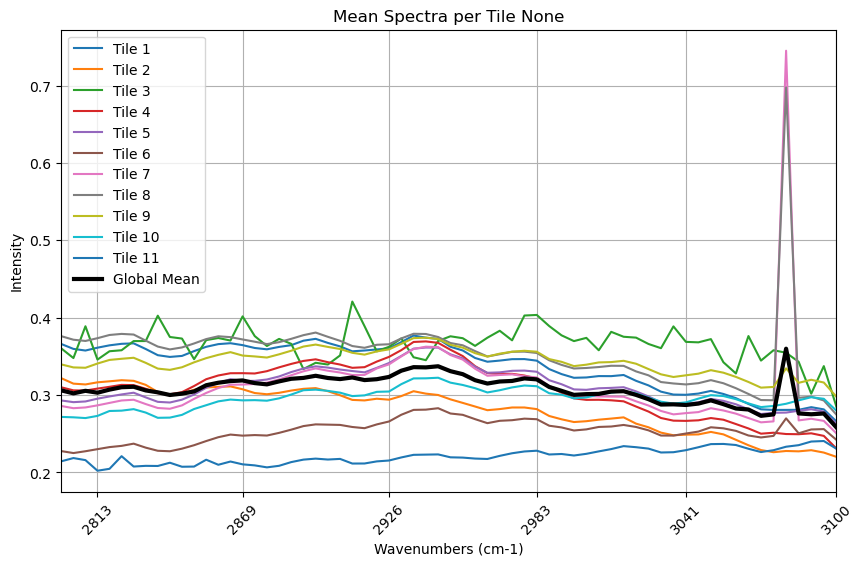

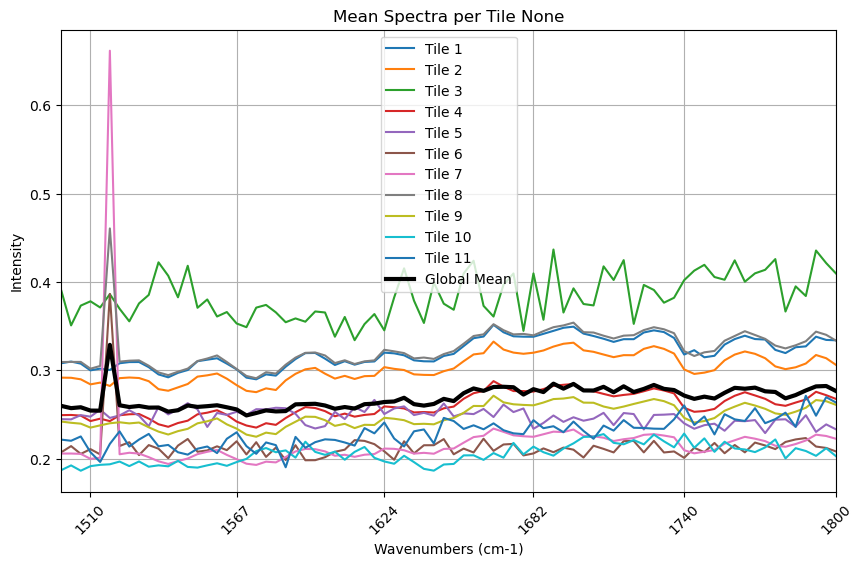

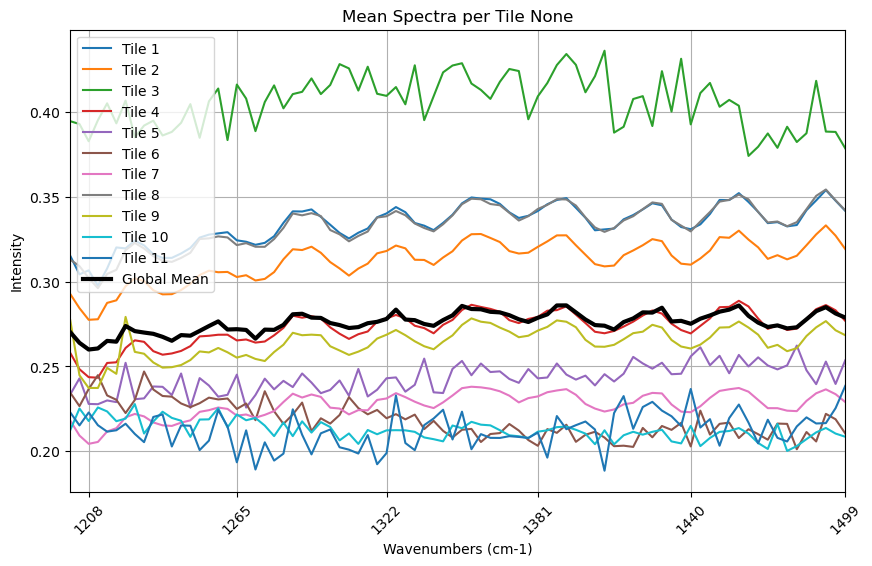

In [46]:
# Print the mean spectra for each tile
for image in lif_data:
    plot_mean_spectra(image["data"], image["wavenumbers"], global_mean=True)

In [22]:
# For each tile in each image, compute the variance and apply a threshold to obtain a binary mask
tqdm_bar = tqdm.tqdm(total=total_tiles, desc="Computing variance over spectral dimensions with threshold")
variance_tiles: list[dict] = []
for image in lif_data:
    variance_image = {"scan_name": image["metadata"]["scan_name"], "variance": []}
    for tile in image["data"]:
        variance = compute_variance_over_spectral_dimensions(tile, gamma_correction_factor=0.3, contrast_enhancement_factor=0.35, low_variance_threshold=0.10)
        variance = cv2.threshold(variance, 0.5, 1, cv2.THRESH_BINARY)[1]
        variance_image["variance"].append(variance)
        tqdm_bar.update(1)
    variance_tiles.append(variance_image)
tqdm_bar.close()

Computing variance over spectral dimensions with threshold: 100%|██████████| 33/33 [00:02<00:00, 15.49it/s]


Text(0.5, 1.0, 'Thresholded variance tile')

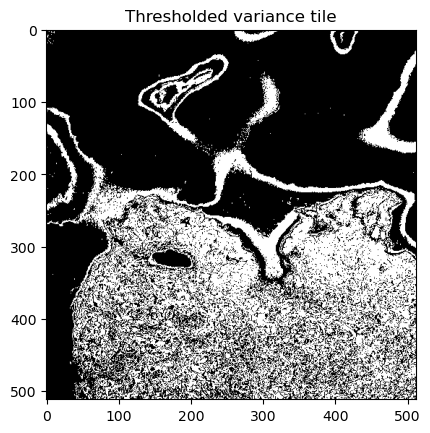

In [29]:
# Inspect one variance tile for debugging
plt.figure()
plt.imshow(variance_tiles[0]["variance"][0], cmap='gray')
plt.title("Thresholded variance tile")

In [34]:
# For each spectral variance map, compute the spatial variance to detect morphological features
tqdm_bar = tqdm.tqdm(total=total_tiles, desc="Computing variance over spatial dimensions")
morph_tiles: list[dict] = []
for image in variance_tiles:
    morph_image = {"scan_name": image["scan_name"], "morph": []}
    for tile in image["variance"]:
        morph = compute_variance_over_region(tile, kernel_size = 3)
        morph_image["morph"].append(morph)
        tqdm_bar.update(1)
    morph_tiles.append(morph_image)
tqdm_bar.close()

Computing variance over spatial dimensions: 100%|██████████| 33/33 [00:00<00:00, 480.25it/s]


Text(0.5, 1.0, 'Thresholded variance tile')

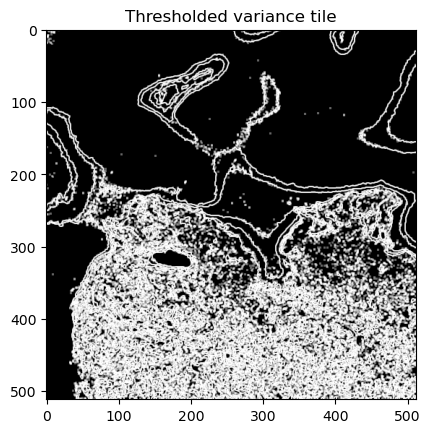

In [35]:
# Inspect one variance tile for debugging
plt.figure()
plt.imshow(morph_tiles[0]["morph"][0], cmap='gray')
plt.title("Thresholded variance tile")

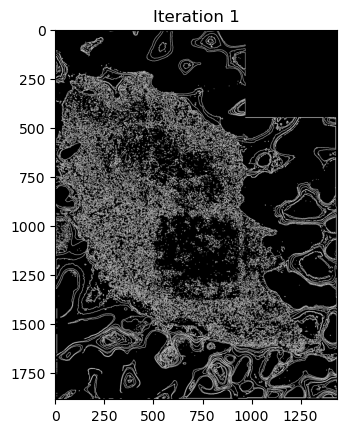

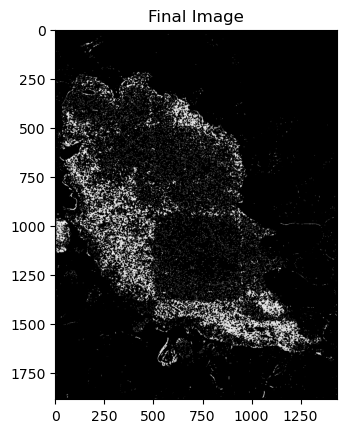

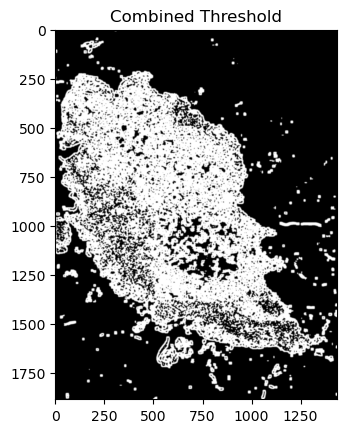

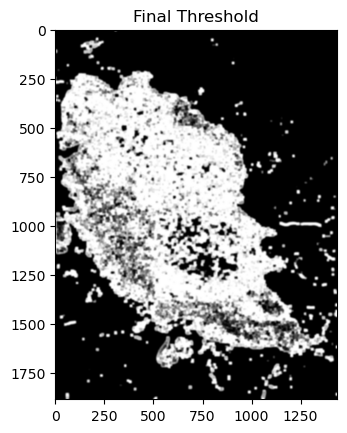

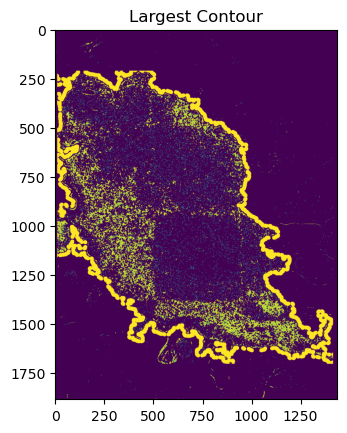

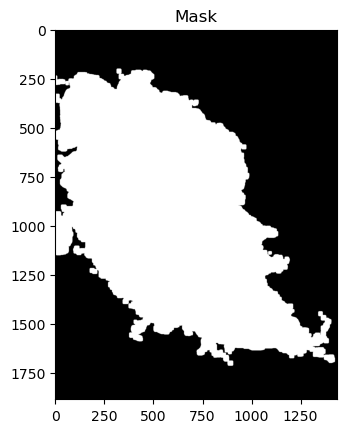

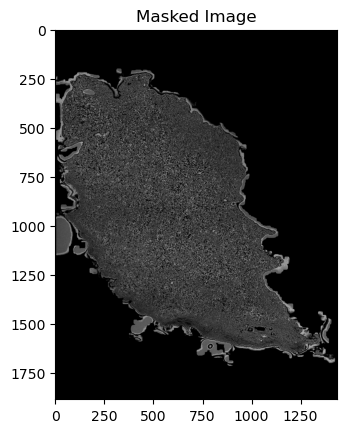

In [ ]:


image = local_variance_map

channels: list[np.ndarray] = []
thresholds: list[np.ndarray] = []
plots: list[tuple[np.ndarray, str]] = []
processed_image: np.ndarray = np.zeros(image.shape, dtype = np.float32)

# Unpack the channels, if the shape is 2D it's a grayscale
if len(image.shape) == 2:
    channels.append(image)
else:
    for channel_id in range(image.shape[2]):
        channel = image[:, :, channel_id]
        channels.append(channel)

win = [5, 15, 9]

for i in range(1):
    img = channels[0]

    # Rescale the image to [0,1]
    img = img.astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img))

    # Rescale the image to [0, 255]
    img = skimage.exposure.rescale_intensity(img, out_range=(0, 255))
    img = img.astype(np.uint8)

    # Calculate local variance
    window_size = win[i]
    variance_img = np.zeros_like(img, dtype=np.float32)
    mean_img = cv2.boxFilter(img.astype(np.float32), -1, (window_size, window_size))
    mean_sq_img = cv2.boxFilter(img.astype(np.float32)**2, -1, (window_size, window_size))
    variance_img = mean_sq_img - mean_img**2

    # Normalize variance to [0,1]
    variance_norm = cv2.normalize(variance_img, None, 0, 1, cv2.NORM_MINMAX)

    # Apply threshold with variance weighting
    # High variance areas will have lower threshold sensitivity
    adaptive_thresh = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 11, 2)

    # Combine with variance information
    result = (variance_norm * 255).astype(np.uint8)
    _, high_var_mask = cv2.threshold(result, 70, 255, cv2.THRESH_BINARY)

    # Final result: regions with high variance
    final = cv2.bitwise_and(img, img, mask=high_var_mask)

    plt.figure()
    plt.imshow(final, cmap='gray')
    plt.title(f"Iteration {i+1}")

    channels[0] = np.where(final > 0, 0, channels[0])


plt.figure()
plt.imshow(channels[0], cmap='gray')
plt.title("Final Image")
plt.show()


# Process each channel
for channel_id in range(len(channels)):


    # Normalize the channel between with min-max
    channels[channel_id] = channels[channel_id].astype(np.float32)
    channels[channel_id] = (channels[channel_id] - np.min(channels[channel_id])) / (np.max(channels[channel_id]) - np.min(channels[channel_id]))

    #channels[channel_id] = gamma_correction(channels[channel_id], gamma=0.7)
    #channels[channel_id] = enhance_contrast(channels[channel_id], saturated_pixels=0.15)

    #channels[channel_id] = cv2.GaussianBlur(channels[channel_id], (9, 9), 9)

    # Rescale the intensity to 0-255 and convert to uint8
    standard = skimage.exposure.rescale_intensity(channels[channel_id], out_range=(0, 255)).astype(np.uint8)
    thresh = cv2.adaptiveThreshold(standard, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 5)
    thresholds.append(thresh)
    break


threshold = np.zeros_like(thresholds[0])
for i in range(len(thresholds)):
    threshold = np.maximum(threshold, thresholds[i])

threshold = cv2.medianBlur(threshold, 5)
threshold = cv2.GaussianBlur(threshold, (5, 5), 9)
plt.figure()
plt.imshow(threshold, cmap='gray')
plt.title("Combined Threshold")
plt.show()

threshold = cv2.erode(threshold, np.ones((5, 5), threshold.dtype), iterations = 1)
threshold = cv2.dilate(threshold, np.ones((5, 5), threshold.dtype), iterations = 2)
threshold = cv2.erode(threshold, np.ones((5, 5), threshold.dtype), iterations = 1)
#hreshold = cv2.adaptiveThreshold(threshold, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 5)

threshold = cv2.erode(threshold, np.ones((5, 5), threshold.dtype), iterations = 1)
threshold = cv2.dilate(threshold, np.ones((5, 5), threshold.dtype), iterations = 2)
threshold = cv2.erode(threshold, np.ones((5, 5), threshold.dtype), iterations = 1)

threshold = cv2.erode(threshold, np.ones((7, 7), threshold.dtype), iterations = 1)
threshold = cv2.dilate(threshold, np.ones((7, 7), threshold.dtype), iterations = 2)
threshold = cv2.erode(threshold, np.ones((7, 7), threshold.dtype), iterations = 1)
threshold = cv2.GaussianBlur(threshold, (9, 9), 9)

plt.figure()
plt.title("Final Threshold")
plt.imshow(threshold, cmap='gray')

plt.show()
contours, _ = cv2.findContours(threshold, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = sorted(contours, key = cv2.contourArea, reverse = True)[0]
x, y, w, h = cv2.boundingRect(largest_contour)

pic = np.ascontiguousarray(np.copy(channels[0]), dtype=processed_image.dtype)
pic = cv2.drawContours(pic, largest_contour, -1, (1.0, 0.0, 0.0), 20)
pic = cv2.rectangle(pic, (x, y), (x + w, y + h), (0.0, 1.0, 0.0), 20)
plt.figure()
plt.imshow(pic)
plt.title("Largest Contour")
plt.show()

# From the largest contour, create a mask
mask = np.zeros_like(threshold, dtype=np.uint8)
cv2.drawContours(mask, [largest_contour], -1, 255, -1)

plt.figure()
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.show()

# Apply the mask to the original image
masked_image = np.zeros_like(local_imgs[0], dtype=np.float32)
masked_image[mask == 255] = local_imgs[0][mask == 255]
masked_image[mask == 0] = 0
plt.figure()
plt.imshow(masked_image[:, :, 0], cmap='gray')
plt.title("Masked Image")
plt.show()

Computed valid pixels


<Axes: title={'center': 'Raman spectra'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

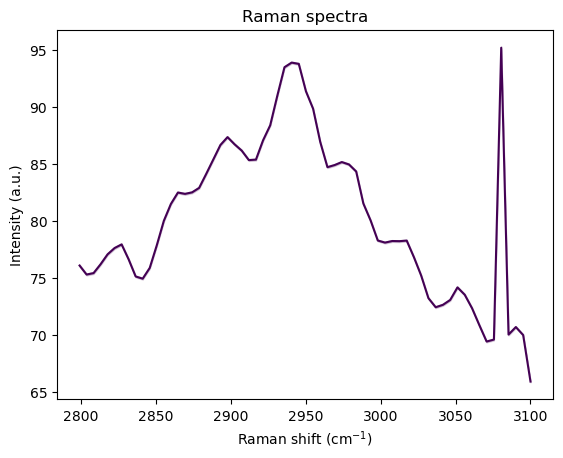

In [ ]:
pipeline = rp.preprocessing.Pipeline([
    #rp.preprocessing.misc.Cropper(region=(700, 1800)),
    rp.preprocessing.despike.WhitakerHayes(),
    rp.preprocessing.denoise.SavGol(window_length=9, polyorder=3),
    #rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax()
])

coordinates = []
valid_pixels = []

# For each pixel of masked_image
for i in range(masked_image.shape[0]):
    for j in range(masked_image.shape[1]):
        if masked_image[i, j, 0] == 0:
            continue
        else:
            if check_zero_range(masked_image[i, j, :]):
                continue
            coordinates.append((i, j))
            valid_pixels.append(masked_image[i, j, :])

print("Computed valid pixels")

coordinates = np.array(coordinates)

valid_pixels = rp.SpectralImage(np.array(valid_pixels), wn[0:local_imgs[0].shape[2]])
rp.plot.mean_spectra(valid_pixels, wn)



In [ ]:
cleaned = pipeline.apply(valid_pixels)

/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


<Axes: title={'center': 'Raman spectra'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

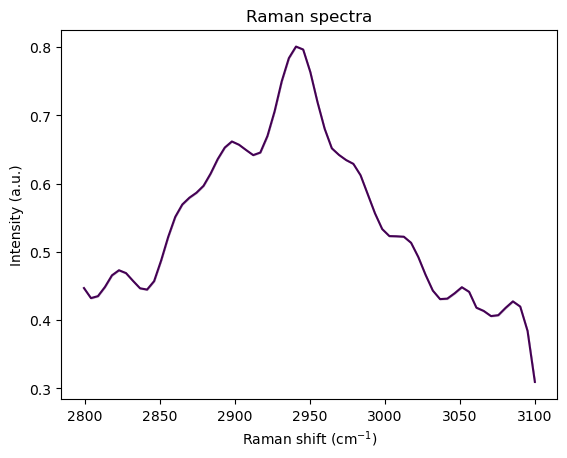

In [ ]:
rp.plot.mean_spectra(cleaned, wn)

In [ ]:
# Reconstruct the image
reconstructed_image = np.zeros_like(masked_image, dtype=np.float32)
for i, (x, y) in enumerate(coordinates):
    #bands = [cleaned[i].band(x) for x in wn[0:masked_image.shape[2]]]
    bands = cleaned[i].tolist()

    reconstructed_image[x, y, :] = cleaned[i].spectral_data

Text(0.5, 1.0, 'Reconstructed Image')

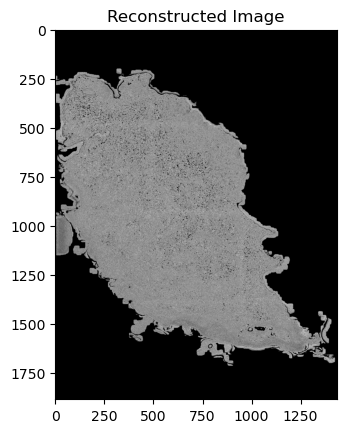

In [ ]:
plt.figure()
plt.imshow(np.mean(reconstructed_image, axis=-1), cmap='gray')
plt.title("Reconstructed Image")

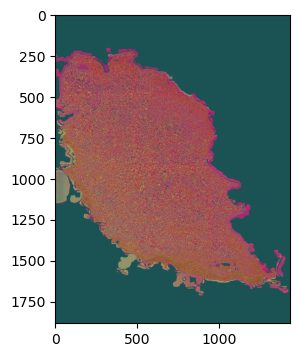

In [ ]:
# Starting from raw_np with shape (H, W, S), compute a 3 dim PCA
pca = PCA(n_components=3)
reshaped_data = reconstructed_image.reshape(-1, reconstructed_image.shape[2])
pca.fit(reshaped_data)
# Transform the data
transformed_data = pca.transform(reshaped_data)
# Reshape back to the original image shape
transformed_data = transformed_data.reshape(reconstructed_image.shape[0], reconstructed_image.shape[1], 3)

# Rescale the PCA components to [0, 1] for visualization
transformed_data = (transformed_data - np.min(transformed_data)) / (np.max(transformed_data) - np.min(transformed_data))


# Plot the PCA components
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(transformed_data, cmap='gray')

In [ ]:
cleaned_np = cleaned.spectral_data
cleaned_tensor = tl.tensor(cleaned_np)
denoised = tensor_denoise(cleaned_tensor, rank=5)

In [ ]:
print(denoised.shape)
print(cleaned_np.shape)
spectral_denoised = rp.SpectralImage(denoised, wn[0:masked_image.shape[2]])

(1166662, 64)
(1166662, 64)


In [ ]:

projections, components = rp.analysis.decompose.PCA(n_components=5).apply(spectral_denoised)

projections = np.array(projections).squeeze()
projections = projections.swapaxes(0, 1)

# reconstruct the image
reconstructed_image = np.zeros((masked_image.shape[0], masked_image.shape[1], 5), dtype=np.float32)
for i, (x, y) in enumerate(coordinates):
    reconstructed_image[x, y, :] = projections[i]



(1166662,) int32 0 9


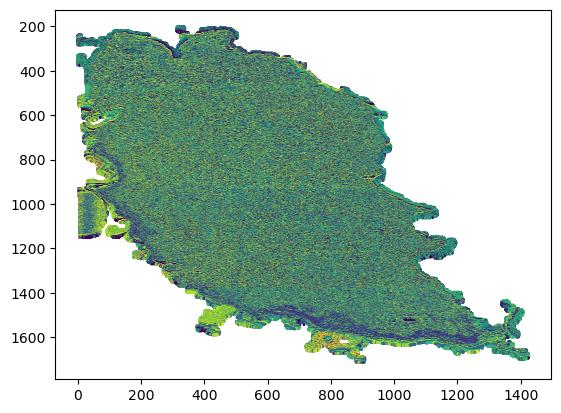

In [ ]:
# Cluster with k-means

kmeans = KMeans(n_clusters=10, random_state=0).fit(projections)
labels = kmeans.labels_

print(labels.shape, labels.dtype, labels.min(), labels.max())

# Plot the labels
plt.figure()
plt.scatter(coordinates[:, 1], coordinates[:, 0], c=labels, s=1)
plt.gca().invert_yaxis()
